# DecoderTCR V0.3: quick start

Score TCR-pMHC recognition from **V/J genes + CDR3 + HLA allele + peptide**. DecoderTCR
reconstructs the full complex and scores it, so you supply only those components. Higher PLL
means more binder-like, and the default model is `DecoderTCR-ESMC_600M`.

Run on a GPU for speed (it also runs on CPU, just slower). Fetch weights and IMGT germlines
once (see the README setup): `uv run python scripts/download_weights.py` then
`uv run stitchrdl -s human`.


In [1]:
from pathlib import Path

import pandas as pd
import torch

import DecoderTCR as dt
from DecoderTCR.utils.model_zoo import MODEL_ZOO

REPO = Path.cwd().parent if Path.cwd().name == "Demo" else Path.cwd()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
print("models:", list(MODEL_ZOO))

device: cuda
models: ['DecoderTCR-ESMC_6B', 'DecoderTCR-ESMC_600M', 'DecoderTCR-ESMC_300M', 'DecoderTCR_3B', 'DecoderTCR_650M']


## 1. Score a single pair

Supply the TCR's V/J genes and CDR3s, the HLA allele, and the peptide. `score_from_components`
returns a one-row DataFrame with the reconstructed chains and a `pll_<model>` column.

In [2]:
result = dt.score_from_components(
    {"trav": "TRAV21", "traj": "TRAJ6", "cdr3a": "CAVRPGGAGPFFVVF",
     "trbv": "TRBV7-9", "trbj": "TRBJ2-7", "cdr3b": "CASSLGQAYEQYF",
     "hla": "HLA-B*27:05", "peptide": "LRVMMLAPF"},
    device=DEVICE)          # add model="DecoderTCR-ESMC_6B" to override the default
result[["peptide", "hla", "ok", "pll_DecoderTCR-ESMC_600M"]]

,peptide,hla,ok,pll_DecoderTCR-ESMC_600M
0,LRVMMLAPF,HLA-B*27:05,True,-0.062469


## 2. Score a batch from a CSV

Pass a CSV (or a DataFrame, or a list of dicts) of components. Columns are case-insensitive
with aliases: `trav, traj, cdr3a, trbv, trbj, cdr3b, hla, peptide` (optional `name, label`).

Here we score 30 TCRs against two `HLA-A*02:01` viral epitopes (influenza M1 `GILGFVFTL` and
CMV pp65 `NLVPMVATV`), each a mix of known binders and non-binders. The PLL is a per-epitope
ranking, so within each epitope sorting by PLL surfaces the binders, and the per-epitope
AUROC quantifies the separation.


In [3]:
from sklearn.metrics import roc_auc_score

pairs = pd.read_csv(REPO / "Demo/sample_data/genes_pairs.csv")
scored = dt.score_from_components(pairs, device=DEVICE)

ok = scored[scored.ok]
print("per-epitope AUROC (binder vs non-binder):")
for pep, g in ok.groupby("peptide"):
    auc = roc_auc_score(g.label, g["pll_DecoderTCR-ESMC_600M"])
    print(f"  {pep}: {auc:.3f}  ({int(g.label.sum())} binders / {int((g.label == 0).sum())} non)")
scored[["name", "peptide", "label", "ok", "pll_DecoderTCR-ESMC_600M"]].sort_values(
    ["peptide", "pll_DecoderTCR-ESMC_600M"], ascending=[True, False]).head(12)


per-epitope AUROC (binder vs non-binder):
  GILGFVFTL: 0.840  (10 binders / 10 non)
  NLVPMVATV: 0.920  (5 binders / 5 non)


,name,peptide,label,ok,pll_DecoderTCR-ESMC_600M
23,V23,GILGFVFTL,1,True,-0.000592
20,V20,GILGFVFTL,1,True,-0.000600
19,V19,GILGFVFTL,1,True,-0.013361
1,V01,GILGFVFTL,1,True,-0.015674
12,V12,GILGFVFTL,1,True,-0.031005
25,V25,GILGFVFTL,1,True,-0.110431
13,V13,GILGFVFTL,0,True,-0.399696
22,V22,GILGFVFTL,0,True,-0.727222
27,V27,GILGFVFTL,1,True,-0.782141
29,V29,GILGFVFTL,0,True,-0.858039


## 3. From the command line

The same single-pair and batch modes are available on the CLI:

```bash
# single pair (components as flags)
python -m DecoderTCR.utils.predict_from_genes \
    --trav TRAV21 --traj TRAJ6 --cdr3a CAVRPGGAGPFFVVF \
    --trbv TRBV7-9 --trbj TRBJ2-7 --cdr3b CASSLGQAYEQYF \
    --hla 'HLA-B*27:05' --peptide LRVMMLAPF -d cuda:0

# batch (a CSV in, a scored CSV out)
python -m DecoderTCR.utils.predict_from_genes \
    -i Demo/sample_data/genes_pairs.csv -o scored.csv -d cuda:0
```

## 4. Embeddings

`dt.embed` returns backbone embeddings for the reconstructed complexes: mean-pooled per complex
(`pool="mean"`), per region (`pool="regions"`), or per residue (`pool=None`).

In [4]:
emb = dt.embed(scored, device=DEVICE)               # (N, d) mean-pooled per complex
print("mean-pooled embeddings:", emb.shape)

regions = dt.embed(scored, pool="regions", device=DEVICE)
print("regions for pair 0:", {r: v.shape for r, v in regions[0].items()})

per_res = dt.embed(scored, pool=None, device=DEVICE)   # list of (L_i, d), one vector per residue
print("per-residue for pair 0:", per_res[0].shape)

mean-pooled embeddings: (30, 1152)


regions for pair 0: {'HLA_a': (1152,), 'HLA_b': (1152,), 'Peptide': (1152,), 'TCR_a': (1152,), 'TCR_b': (1152,)}


per-residue for pair 0: (1025, 1152)


## 5. Benchmark results

See [`../results/`](../results/) for all figures and per-model CSVs. The cross-benchmark
summary at a glance:

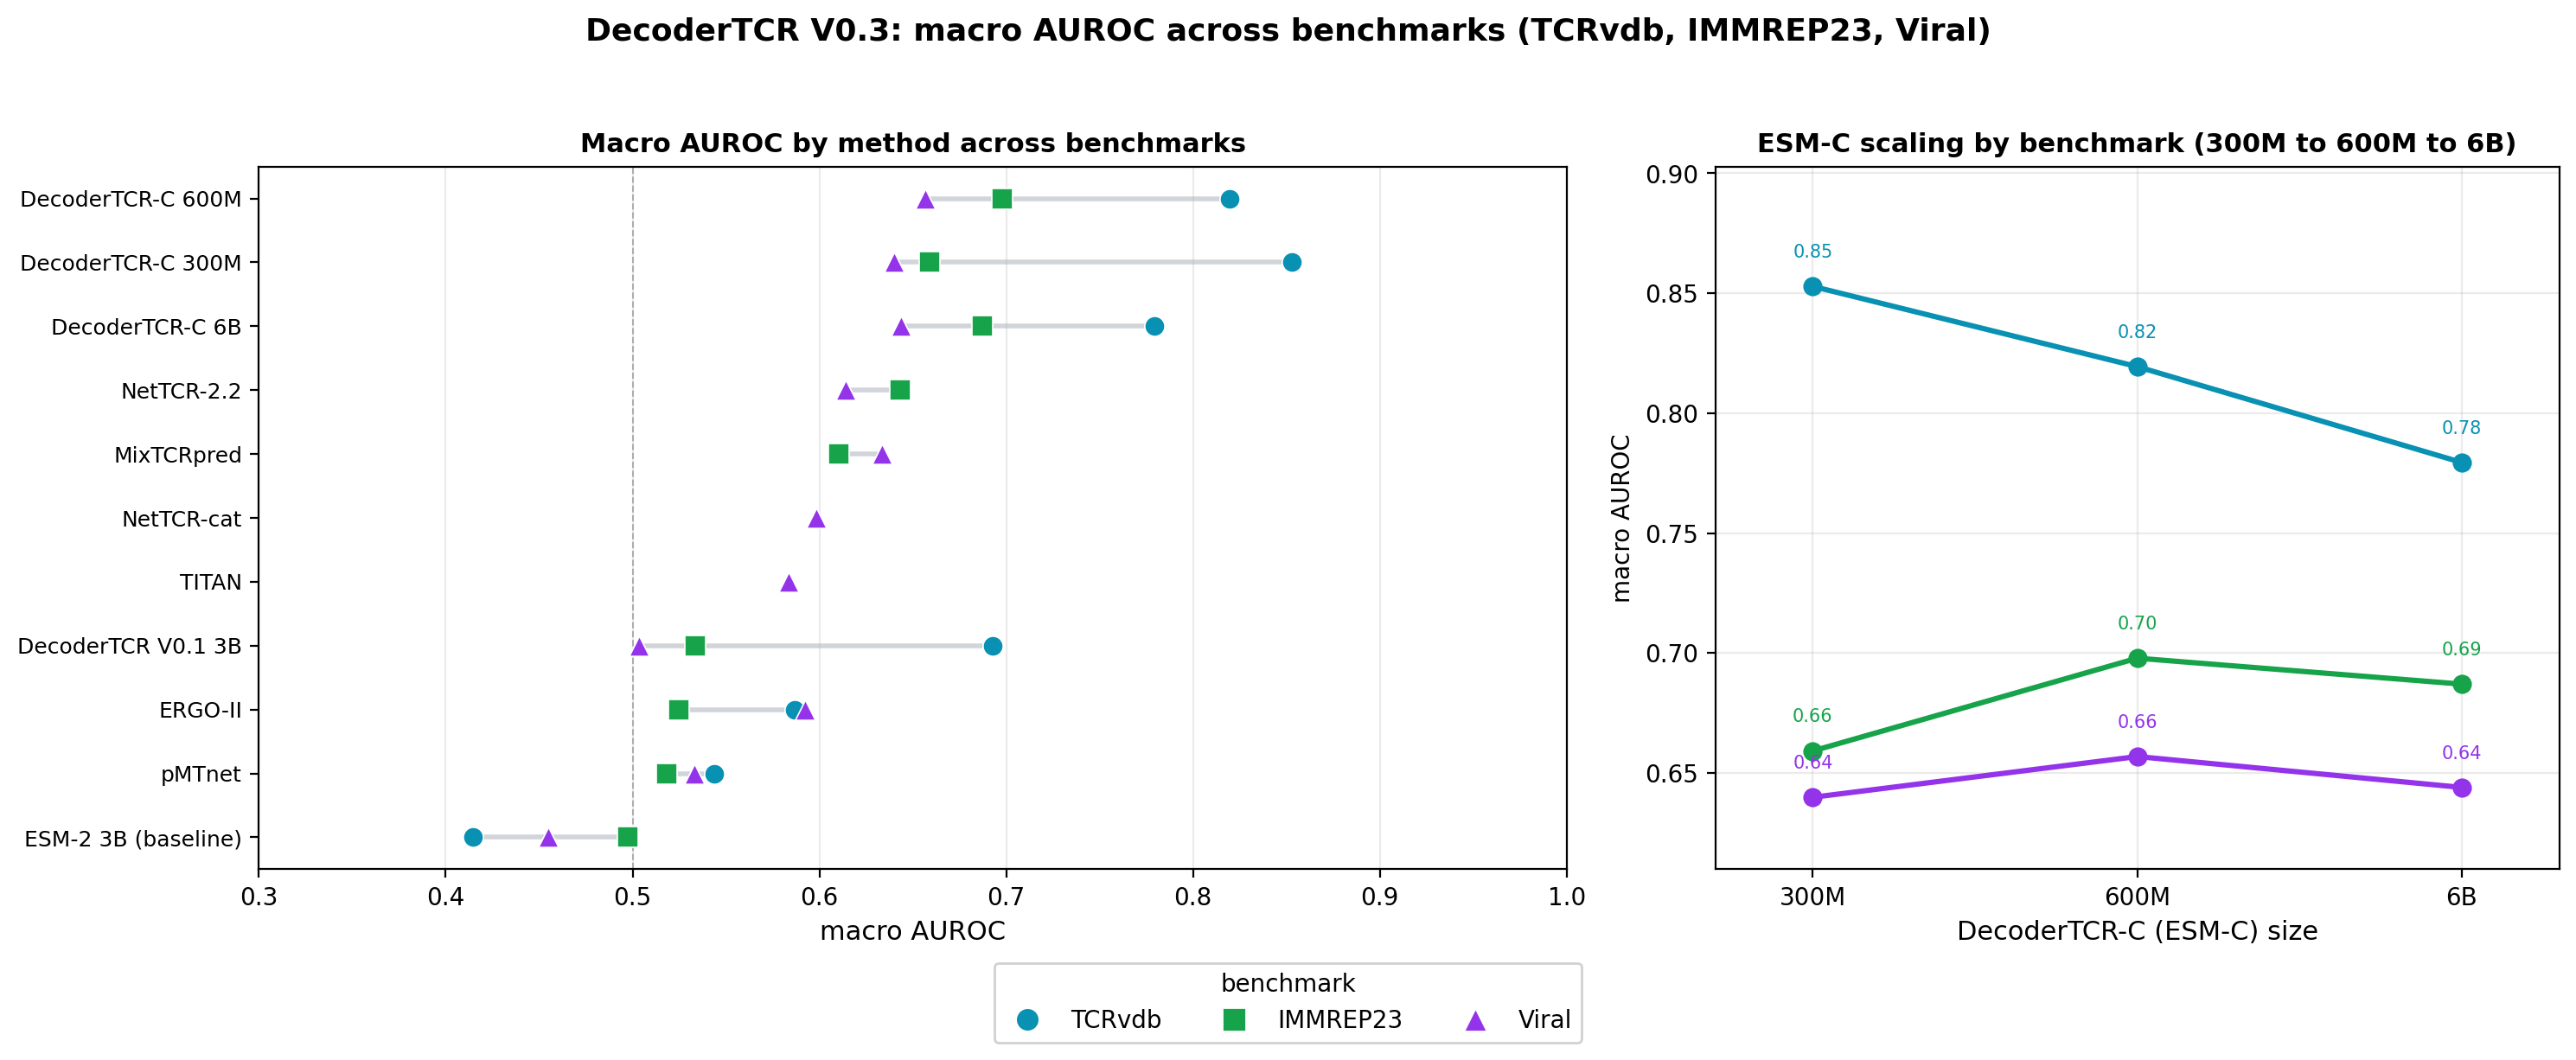

In [5]:
from IPython.display import Image
Image(filename=str(REPO / "results/figures/summary_dotplot_scaling.png"))